# Modifying ABCMB

In this script we demonstrate how to efficiently implement a new physics fluid species to the cosmological model.

TODO: Discuss how to add new species, how to handle delta_idx? Not by the user?

## Setup

In [2]:
import sys
sys.path.append('..')

from ABCMB.main import Model
import ABCMB.spectrum as spectrum
from ABCMB.species import Fluid, StandardFluid, BackgroundFluid
import ABCMB.constants as cnst

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import equinox as eqx

## Example: $w_0w_a$ (Dynamical Dark Energy)

The user might also wish to implement a species without any inhomogeneity. Such a species would only contribute to the background portion of the Friedmann equation, i.e. modify Hubble in an interesting way. 

One such model, the dynamical dark energy, has gained much attention in light of the recent DESI data. We demonstrate here how to implement such a model, and similar models that do not require a perturbation Boltzmann hierarchy. 

Since the model has no perturbations, it is no longer necessary to implement the functions y_ini() and y_prime(). This means the class w0wa should not inherit from AbstractPerturbedFluid, which requires that all children implement these functions. Instead, we will go one step up the chain and inherit from the perturbations-free parent class, AbstractFluid.

In [19]:
class DynamicalDarkEnergy(BackgroundFluid, strict=True):

    name = "DynamicalDarkEnergy"
    
    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Parameterized as the redshift behavior based on its energy density today.
        rho = rho0 x a^{-3(1+w)}
        """
        # Energy density today
        rho0 = params["omega_Lambda"] * (3.*cnst.H0_over_h**2/8./jnp.pi/cnst.G)
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        
        return rho0 * a**(-3.*(1.+w))

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        """
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        return w*self.rho(lna, params)

    def cs2(self, lna, params):
        """
        Sound speed squared.
        This is not used, but for good programming structure it must be instantiated.
        Set to some trivial value. 
        """
        return 0.

## Example: SIDR

We will first look at the strongly self-interacting dark radiation model. This scenario can be realised by a secluded dark sector of massless particles, whose self-interaction remains effective throughout cosmological history $\left(\frac{\Gamma}{H}\gg 1\right)$. Such interaction reduces the full Boltzmann hierarchy required for a free-streaming species down to the $\ell=0, 1$ modes.

Here, the user can define a new SIDR class, which inherits from ABCMB's template class, StandardFluid.

In [3]:
class SIDR(StandardFluid):

    name = "SIDR"
    
    # Number of modes in the Boltzmann Hierarchy
    num_ell_modes = 2 # Non free-streaming species only require density and velocity perturbations

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)
    
    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Here it is parameterized in terms of N_IDR, the effective number
        of extra neutrino species. 
        """
        # Energy density in one neutrino species
        # rho1nu = params["omega_nu"]/params["N_ur"] * (3.*cnst.H0_over_h**2/8./jnp.pi/cnst.G) / jnp.exp(lna)**4
        # return params["N_IDR"] * rho1nu
        # ZZ: Fix units!!!
        T4 = params["N_IDR"]/params['stat_f_idr'] * 7./8 / (11./4.)**(4./3) * params['TCMB0']**4 / jnp.exp(lna)**4
        return jnp.pi**2/30. * params['stat_f_idr'] * T4

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        For fully relativistic species this is simply rho/3.
        """
        return self.rho(lna, params)/3.

    def cs2(self, lna, params):
        """
        Sound speed squared.
        For fully relativistic species cs2 = 1/3.
        """
        return 1./3.

    def y_ini(self, k, tau_ini, om, args):
        """
        Adiabatic superhorizon initial conditions for SIDR.
        For all relativistic species they are matched to neutrinos.
        """
        params = args
        R_nu = params['R_nu']

        delta = - (k*tau_ini)**2/3. * (1.-om*tau_ini/5.)
        theta = - k*(k*tau_ini)**3/36./(4.*R_nu+15.) \
                * (4.*R_nu+11.+12.-3.*(8.*R_nu**2+50.*R_nu+275.)/20./(2.*R_nu+15.)*tau_ini*om)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params = args
        aH = BG.aH(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4.

        return jnp.array([delta_prime, theta_prime])

In [4]:
lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : False,
    "output_Pk" : False,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17
}
user_species = (SIDR,)

In [5]:
SIDRmodel = Model(specs, user_species)

In [6]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1193,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    'T_nu': (4./11.)**(1./3.),
    'N_IDR' : jnp.array(.1),
    'stat_f_idr' : jnp.array(0.875)
}

In [7]:
params = SIDRmodel.add_derived_parameters(params)

In [12]:
rho_r = 0.
for s in SIDRmodel.species_list:
    rho_r += s.rho(-15., params)
rho_r *= jnp.exp(-15.)**4

In [14]:
rho_r/ (3 * cnst.H0_over_h**2/8/jnp.pi/cnst.G)

Array(4.18691533e-05, dtype=float64)

In [11]:
rho_m / (3 * cnst.H0_over_h**2/8/jnp.pi/cnst.G)

Array(0.1418, dtype=float64)

In [29]:
params = SIDRmodel.add_derived_parameters(params)
BG = SIDRmodel.get_BG(params)

In [31]:
BG.aH(-7.0, params)

Array(0.00478525, dtype=float64)

In [32]:
SIDRmodel.species_list

(DarkEnergy(delta_idx=2, name='DarkEnergy'),
 ColdDarkMatter(delta_idx=2, num_ell_modes=1, name='ColdDarkMatter'),
 Baryon(delta_idx=3, num_ell_modes=2, name='Baryon'),
 Photon(
   delta_idx=5,
   num_ell_modes=24,
   name='Photon',
   num_F_ell_modes=13,
   num_G_ell_modes=11
 ),
 MasslessNeutrino(delta_idx=29, num_ell_modes=18, name='MasslessNeutrino'),
 SIDR(delta_idx=47, num_ell_modes=2, name='SIDR'))

In [36]:
[s.rho(0., params) for s in SIDRmodel.species_list]

[Array(3323.33272986, dtype=float64),
 Array(1257.03168816, dtype=float64),
 Array(237.07638712, dtype=float64),
 Array(0.26057058, dtype=float64),
 Array(0.18013626, dtype=float64),
 Array(2.27345268e-17, dtype=float64, weak_type=True)]

In [ ]:
class_params = {
    "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, lCl",
    #"temperature_contributions" : "tsw",
    "P_k_max_1/Mpc" : specs["output_k_max"],
    "l_max_scalars" : lmax,
    "k_output_values" : "0.001, 0.01, 0.1, 0.4",
    #"k_output_values" : kstr,
    "lensing" : "yes" if specs["lensing"] else "no",
    "H0": params["h"]*100,
    "omega_b": params["omega_b"],
    "omega_cdm": params["omega_cdm"],
    "A_s" : params["A_s"],
    "n_s" : params["n_s"],
    "N_ur": params["N_ur"],
    "YHe": params["YHe"],
    "N_ncdm": params["N_ncdm"],
    #"reio_parametrization" : "reio_none",
    "reio_parametrization" : "reio_camb",
    "z_reio" : 11,
    "reionization_width" : 0.5,
    "helium_fullreio_redshift" : 3.5,
    "helium_fullreio_width" : 0.5,
    "reionization_exponent" : 1.5,
    "l_max_g": specs["l_max_g"],
    "l_max_pol_g": specs["l_max_pol_g"],
    "l_max_ur": specs["l_max_ur"], 
    "l_max_ncdm":specs["l_max_ncdm"],
    "radiation_streaming_trigger_tau_over_tau_k" : 20000,
    "radiation_streaming_trigger_tau_c_over_tau" : 2000,
    "ur_fluid_trigger_tau_over_tau_k" : 10000, 
    "ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
class_lcdm = Class()
class_lcdm.set(class_params)
if params["N_ncdm"] > 0:
    class_lcdm.set({"m_ncdm": params["m_ncdm"], "T_ncdm": params["T_ncdm"]})
class_lcdm.compute()

In [23]:
CLASS_SIDR = np.loadtxt('data/idr00_cl.dat')

In [24]:
CLASS_SIDR_ell = CLASS_SIDR[:,0]
CLASS_SIDR_tt = CLASS_SIDR[:,1]

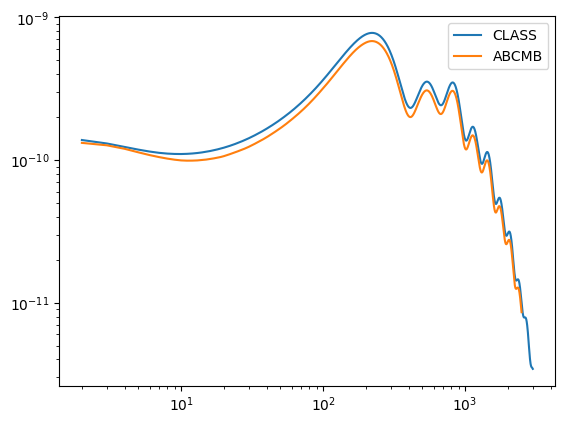

In [26]:
plt.loglog(CLASS_SIDR_ell,  CLASS_SIDR_tt, label='CLASS')
plt.loglog(ell, ell * (ell + 1) * ABCl[0]/(2*jnp.pi), label='ABCMB')
plt.legend()

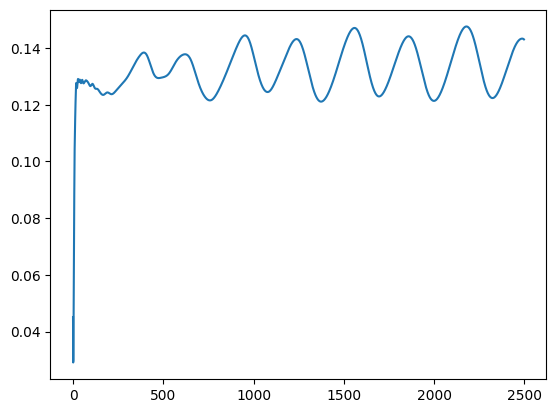

In [31]:
plt.plot((CLASS_SIDR_tt[:2499] - (ell * (ell + 1) * ABCl[0]/(2*jnp.pi)))/ CLASS_SIDR_tt[:2499])

## Example: Interacting DM-DR

For the last example we demonstrate how one could implement interacting species in ABCMB. 

## Template: Define your own species!